In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Set dataset path from your Drive
DATA_PATH = "/content/drive/MyDrive/nirma/Road-Accident/Road.csv"

print("Path exists:", os.path.exists(DATA_PATH))
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found at: {DATA_PATH}")

Path exists: True


In [4]:
# Load CSV safely
try:
    df_raw = pd.read_csv(DATA_PATH)
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding="latin1")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (12316, 36)


,Accident severity,Age band of casualty,Age band of driver,Area accident occured,Casualty class,Casualty severity,Cause of accident,Day of week,Defect of vehicle,Driving experience,...,Vehicle driver relation,Vehicle movement,Weather conditions,Work of casuality,High Severity Count,High Severity Rate,Hour of Day,Number of casualties,Number of Records,Number of vehicles involved
0,Slight Injury,na,18-30,Residential areas,na,na,Moving Backward,Monday,No defect,1-2yr,...,Employee,Going straight,Normal,NaN,0,0,17,2,1,2
1,Slight Injury,na,31-50,Office areas,na,na,Overtaking,Monday,No defect,Above 10yr,...,Employee,Going straight,Normal,NaN,0,0,17,2,1,2
2,Serious Injury,31-50,18-30,Recreational areas,Driver or rider,3,Changing lane to the left,Monday,No defect,1-2yr,...,Employee,Going straight,Normal,Driver,1,1,17,2,1,2
3,Slight Injury,18-30,18-30,Office areas,Pedestrian,3,Changing lane to the right,Sunday,No defect,5-10yr,...,Employee,Going straight,Normal,Driver,0,0,1,2,1,2
4,Slight Injury,na,18-30,Industrial areas,na,na,Overtaking,Sunday,No defect,2-5yr,...,Employee,Going straight,Normal,NaN,0,0,1,2,1,2


In [5]:
# Quick schema info
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nColumns:")
for c in df_raw.columns:
    print(c)

Rows: 12316
Columns: 36

Columns:
Accident severity
Age band of casualty
Age band of driver
Area accident occured
Casualty class
Casualty severity
Cause of accident
Day of week
Defect of vehicle
Driving experience
Educational level
Fitness of casuality
Lanes or Medians
Light conditions
Owner of vehicle
Pedestrian movement
Road allignment
Road surface conditions
Road surface type
Service year of vehicle
Sex of casualty
Sex of driver
Time
Type of collision
Type of vehicle
Types of Junction
Vehicle driver relation
Vehicle movement
Weather conditions
Work of casuality
High Severity Count
High Severity Rate
Hour of Day
Number of casualties
Number of Records
Number of vehicles involved


In [6]:
# Normalize missing values
df = df_raw.copy()

def normalize_text(x):
    if isinstance(x, str):
        x = x.strip()
        if x.lower() in ["", "na", "n/a", "null", "none"]:
            return np.nan
    return x

df = df.applymap(normalize_text)

missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_report.head(20)

,missing_count,missing_pct
Age band of casualty,4443,36.08
Sex of casualty,4443,36.08
Casualty severity,4443,36.08
Casualty class,4443,36.08
Defect of vehicle,4427,35.95
Service year of vehicle,3928,31.89
Work of casuality,3198,25.97
Fitness of casuality,2635,21.39
Type of vehicle,950,7.71
Types of Junction,887,7.20


In [7]:
# Parse time and create hour/time-band features
if "Time" in df.columns:
    df["Time_parsed"] = pd.to_datetime(df["Time"], errors="coerce", dayfirst=True)
    df["hour_from_time"] = df["Time_parsed"].dt.hour
else:
    df["Time_parsed"] = pd.NaT
    df["hour_from_time"] = np.nan

if "Hour of Day" in df.columns:
    df["Hour of Day"] = pd.to_numeric(df["Hour of Day"], errors="coerce")
    df["hour_final"] = df["Hour of Day"].fillna(df["hour_from_time"])
else:
    df["hour_final"] = df["hour_from_time"]

def hour_band(h):
    if pd.isna(h):
        return "Unknown"
    h = int(h)
    if 5 <= h < 12:
        return "Morning"
    if 12 <= h < 17:
        return "Afternoon"
    if 17 <= h < 21:
        return "Evening"
    return "Night"

df["time_band"] = df["hour_final"].apply(hour_band)

df[["Time", "Time_parsed", "hour_final", "time_band"]].head()

,Time,Time_parsed,hour_final,time_band
0,30-12-1899 17:02:00,1899-12-30 17:02:00,17,Evening
1,30-12-1899 17:02:00,1899-12-30 17:02:00,17,Evening
2,30-12-1899 17:02:00,1899-12-30 17:02:00,17,Evening
3,30-12-1899 01:06:00,1899-12-30 01:06:00,1,Night
4,30-12-1899 01:06:00,1899-12-30 01:06:00,1,Night


In [8]:
# Convert known numeric fields
numeric_cols = [
    "High Severity Count",
    "High Severity Rate",
    "Hour of Day",
    "Number of casualties",
    "Number of Records",
    "Number of vehicles involved"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion done.")

Numeric conversion done.


In [9]:
# Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)

print("Duplicates removed:", before - after)
print("Current shape:", df.shape)

Duplicates removed: 0
Current shape: (12316, 40)


In [10]:
# Create analysis-ready dataset
df_model = df.copy()

cat_cols = df_model.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df_model[col] = df_model[col].fillna("Unknown")

severity_map = {
    "Slight Injury": 1,
    "Serious Injury": 2,
    "Fatal injury": 3
}

if "Accident severity" in df_model.columns:
    df_model["severity_score"] = df_model["Accident severity"].map(severity_map)

print("Analysis-ready shape:", df_model.shape)
df_model.head()

Analysis-ready shape: (12316, 41)


,Accident severity,Age band of casualty,Age band of driver,Area accident occured,Casualty class,Casualty severity,Cause of accident,Day of week,Defect of vehicle,Driving experience,...,High Severity Rate,Hour of Day,Number of casualties,Number of Records,Number of vehicles involved,Time_parsed,hour_from_time,hour_final,time_band,severity_score
0,Slight Injury,Unknown,18-30,Residential areas,Unknown,Unknown,Moving Backward,Monday,No defect,1-2yr,...,0,17,2,1,2,1899-12-30 17:02:00,17,17,Evening,1
1,Slight Injury,Unknown,31-50,Office areas,Unknown,Unknown,Overtaking,Monday,No defect,Above 10yr,...,0,17,2,1,2,1899-12-30 17:02:00,17,17,Evening,1
2,Serious Injury,31-50,18-30,Recreational areas,Driver or rider,3,Changing lane to the left,Monday,No defect,1-2yr,...,1,17,2,1,2,1899-12-30 17:02:00,17,17,Evening,2
3,Slight Injury,18-30,18-30,Office areas,Pedestrian,3,Changing lane to the right,Sunday,No defect,5-10yr,...,0,1,2,1,2,1899-12-30 01:06:00,1,1,Night,1
4,Slight Injury,Unknown,18-30,Industrial areas,Unknown,Unknown,Overtaking,Sunday,No defect,2-5yr,...,0,1,2,1,2,1899-12-30 01:06:00,1,1,Night,1


Counts:
Accident severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Percent:
Accident severity
Slight Injury     84.56
Serious Injury    14.15
Fatal injury       1.28
Name: proportion, dtype: float64


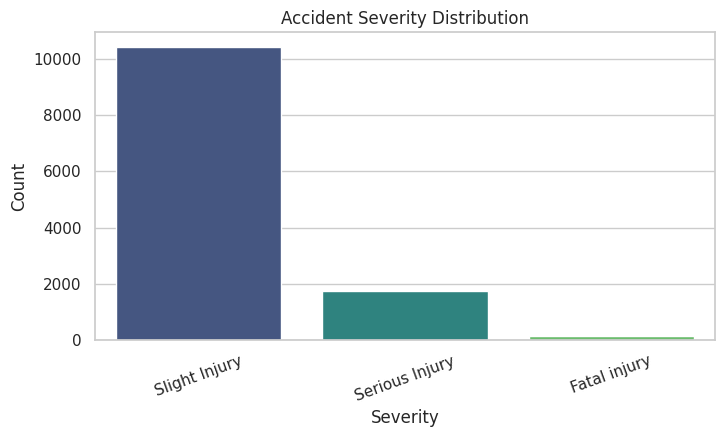

In [11]:
# Severity distribution
if "Accident severity" in df_model.columns:
    counts = df_model["Accident severity"].value_counts(dropna=False)
    pct = (df_model["Accident severity"].value_counts(normalize=True) * 100).round(2)

    print("Counts:")
    print(counts)
    print("\nPercent:")
    print(pct)

    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_model, x="Accident severity", order=counts.index, palette="viridis")
    plt.title("Accident Severity Distribution")
    plt.xlabel("Severity")
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.show()

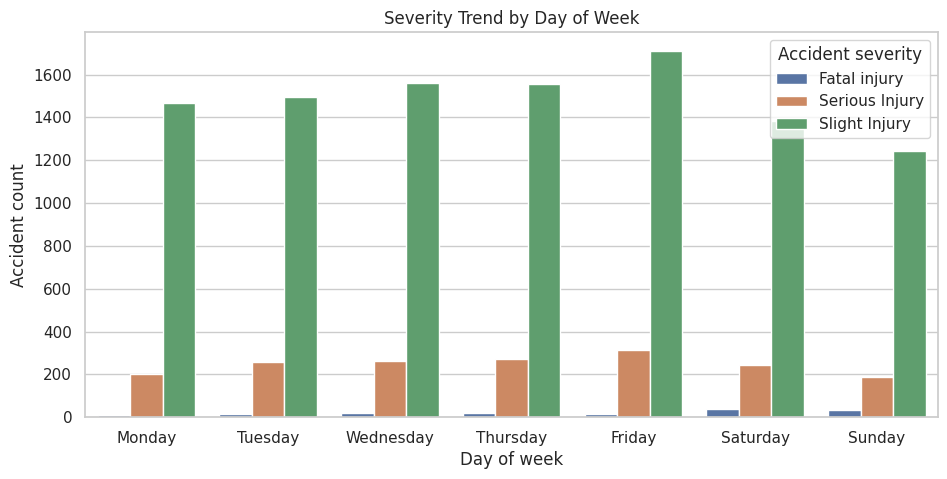

In [12]:
# Day-wise severity trend
if "Day of week" in df_model.columns and "Accident severity" in df_model.columns:
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    day_summary = (
        df_model.groupby(["Day of week", "Accident severity"], dropna=False)
        .size()
        .reset_index(name="accident_count")
    )

    day_summary["Day of week"] = pd.Categorical(day_summary["Day of week"], categories=day_order, ordered=True)
    day_summary = day_summary.sort_values("Day of week")

    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=day_summary,
        x="Day of week",
        y="accident_count",
        hue="Accident severity",
        estimator=sum,
        errorbar=None
    )
    plt.title("Severity Trend by Day of Week")
    plt.xlabel("Day of week")
    plt.ylabel("Accident count")
    plt.show()

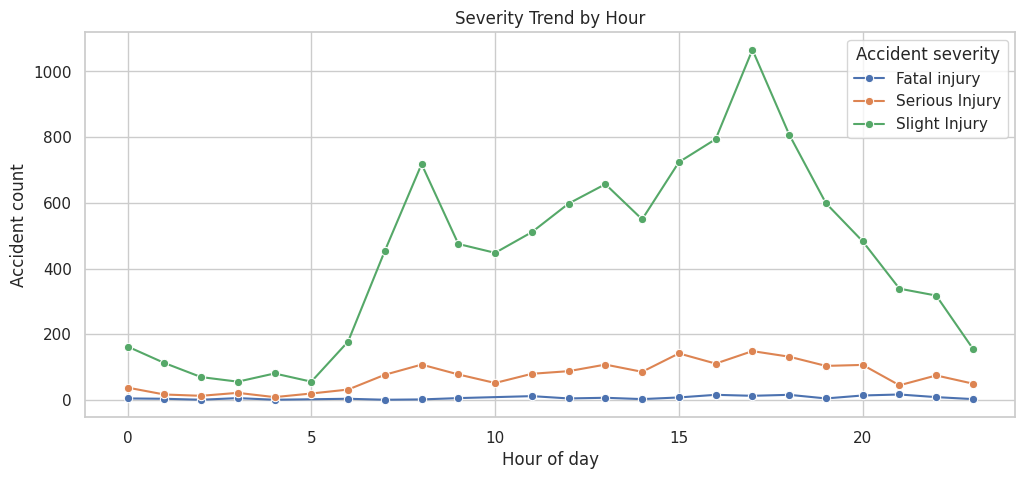

In [13]:
# Hour-wise severity trend
if "Accident severity" in df_model.columns:
    hour_summary = (
        df_model.groupby(["hour_final", "Accident severity"], dropna=False)
        .size()
        .reset_index(name="accident_count")
        .sort_values("hour_final")
    )

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=hour_summary,
        x="hour_final",
        y="accident_count",
        hue="Accident severity",
        marker="o"
    )
    plt.title("Severity Trend by Hour")
    plt.xlabel("Hour of day")
    plt.ylabel("Accident count")
    plt.show()

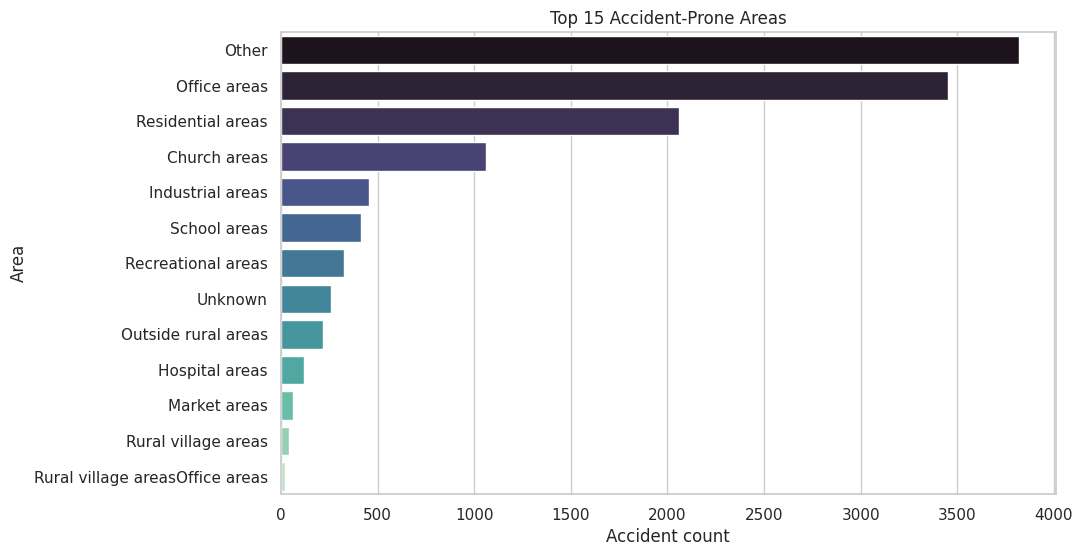

In [14]:
# Area hotspot analysis
if "Area accident occured" in df_model.columns:
    top_areas = df_model["Area accident occured"].value_counts().head(15).reset_index()
    top_areas.columns = ["Area accident occured", "accident_count"]

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_areas, y="Area accident occured", x="accident_count", palette="mako")
    plt.title("Top 15 Accident-Prone Areas")
    plt.xlabel("Accident count")
    plt.ylabel("Area")
    plt.show()

In [15]:
# Create Tableau/KNIME export tables
df_export = df_model.copy()

severity_distribution = (
    df_export.groupby("Accident severity", dropna=False)
    .size()
    .reset_index(name="accident_count")
)

severity_by_day = pd.DataFrame()
if "Day of week" in df_export.columns:
    severity_by_day = (
        df_export.groupby(["Day of week", "Accident severity"], dropna=False)
        .size()
        .reset_index(name="accident_count")
    )

severity_by_hour = (
    df_export.groupby(["hour_final", "Accident severity"], dropna=False)
    .size()
    .reset_index(name="accident_count")
    .sort_values("hour_final")
)

severity_by_area = pd.DataFrame()
if "Area accident occured" in df_export.columns:
    severity_by_area = (
        df_export.groupby(["Area accident occured", "Accident severity"], dropna=False)
        .size()
        .reset_index(name="accident_count")
        .sort_values("accident_count", ascending=False)
    )

hotspot_area_junction = pd.DataFrame()
if "Area accident occured" in df_export.columns and "Types of Junction" in df_export.columns:
    hotspot_area_junction = (
        df_export.groupby(["Area accident occured", "Types of Junction"], dropna=False)
        .size()
        .reset_index(name="accident_count")
        .sort_values("accident_count", ascending=False)
    )

print("Export tables prepared.")

Export tables prepared.


In [16]:
# Save outputs to Drive folder
OUT_DIR = "/content/drive/MyDrive/nirma/Road-Accident"
os.makedirs(OUT_DIR, exist_ok=True)

df_export.to_csv(f"{OUT_DIR}/road_cleaned_for_knime_tableau.csv", index=False)
severity_distribution.to_csv(f"{OUT_DIR}/severity_distribution.csv", index=False)
severity_by_hour.to_csv(f"{OUT_DIR}/severity_by_hour.csv", index=False)

if not severity_by_day.empty:
    severity_by_day.to_csv(f"{OUT_DIR}/severity_by_day.csv", index=False)

if not severity_by_area.empty:
    severity_by_area.to_csv(f"{OUT_DIR}/severity_by_area.csv", index=False)

if not hotspot_area_junction.empty:
    hotspot_area_junction.to_csv(f"{OUT_DIR}/hotspot_area_junction.csv", index=False)

print("All files saved in:", OUT_DIR)

All files saved in: /content/drive/MyDrive/nirma/Road-Accident


In [17]:
# Optional: quick check of generated files
import glob

generated = glob.glob("/content/drive/MyDrive/nirma/Road-Accident/*.csv")
for f in generated:
    print(f)

/content/drive/MyDrive/nirma/Road-Accident/Road.csv
/content/drive/MyDrive/nirma/Road-Accident/road_cleaned_for_knime_tableau.csv
/content/drive/MyDrive/nirma/Road-Accident/severity_distribution.csv
/content/drive/MyDrive/nirma/Road-Accident/severity_by_hour.csv
/content/drive/MyDrive/nirma/Road-Accident/severity_by_day.csv
/content/drive/MyDrive/nirma/Road-Accident/severity_by_area.csv
/content/drive/MyDrive/nirma/Road-Accident/hotspot_area_junction.csv
